# Taylor-Green Vortex — Pseudospectral simulation with JAX

We solve the 3-D incompressible Navier-Stokes equations on a triply-periodic domain $[0, 2\pi]^3$.

| Component | Choice |
|-----------|--------|
| Spatial | Fourier pseudospectral (FFT) |
| Dealiasing | 2/3 rule — zero modes with $\lvert k_i \rvert > N/3$ |
| Incompressibility | Leray projection in Fourier space |
| Time stepping | $2^{nd}$-order Runge-Kutta with Heun predictor-corrector |

**Initial condition** (Taylor-Green vortex)
$$u = \sin x \cos y \cos z, \quad v = -\cos x \sin y \cos z, \quad w = 0$$

---

**Nondimensionalisation**

Starting from the dimensional incompressible Navier-Stokes equations:
$$\frac{\partial \mathbf{u}^*}{\partial t^*} + (\mathbf{u}^* \cdot \nabla)\mathbf{u}^* = -\frac{1}{\rho}\nabla p^* + \nu_1 \nabla^2 \mathbf{u}^*$$

Here, $\mathbf{u}$ is the velocity and $p$ the pressure. The viscosity is defined here as $\nu_1$ as we will use $\nu$ for the final nondimensional form later. We introduce a characteristic velocity $U$ and length scale $L$ and define nondimensional variables $\mathbf{u} = \mathbf{u}^*/U$, $t = t^* U/L$, $p = p^*/\rho U^2$. The equations become:
$$\frac{\partial \mathbf{u}}{\partial t} + (\mathbf{u} \cdot \nabla)\mathbf{u} = -\nabla p + \frac{1}{Re} \nabla^2 \mathbf{u}, \qquad Re = \frac{UL}{\nu_1}$$

For the Taylor-Green vortex the natural scales are $U = 1$ (peak velocity of the initial condition) and $L = 1$ (set by the initial condition), giving $\nu = 1/Re$.

In [ ]:
# ── Google Colab GPU setup ────────────────────────────────────────────────────
# Skip this cell if running locally.
#
# On Colab:
#   1. Runtime → Change runtime type → T4 GPU
#   2. Uncomment the line below and run this cell
#   3. Runtime → Restart runtime
#   4. Then run all cells from the top
#
!pip install -q --upgrade "jax[cuda12]"

In [ ]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import time

# Enabling 64-bit floats for precision. JAX's default is 32-bit.
jax.config.update("jax_enable_x64", True)

print(f"Devices: {jax.devices()}")

Devices: [CudaDevice(id=0)]


## Parameters

In [ ]:
N        = 64            # grid points per dimension
Re       = 1600          # Reynolds number
nu       = 1.0 / Re      # kinematic viscosity
L        = 2.0 * np.pi   # domain length in each dimension
dt       = 0.01          # time step
T        = 20.0          # end time
n_steps  = int(T / dt)
log_freq = 50            # save diagnostics every this many steps

print(f"Grid: {N}³ = {N**3:,} points")
print(f"Steps: {n_steps}  (dt={dt}, T={T})")
print(f"Re={Re}, nu={nu:.2e}")

Grid: 64³ = 262,144 points
Steps: 2000  (dt=0.01, T=20.0)
Re=1600, nu=6.25e-04


## Grid and Wavenumbers

The wavenumber grid uses `jnp.fft.fftfreq`, which returns integers
$0, 1, \ldots, N/2-1, -N/2, \ldots, -1$.

The **2/3 dealiasing mask** zeroes Fourier modes with $|k_i| > (2/3)k_{max}$, where $k_{max}=N/2$, before any physical-space multiplication.

In [ ]:
# Physical-space coordinate (same in all three directions by symmetry)
x = jnp.linspace(0.0, L, N, endpoint=False)
X, Y, Z = jnp.meshgrid(x, x, x, indexing='ij')  # shape (N, N, N)

# Integer wavenumbers
k = jnp.fft.fftfreq(N, d=1.0 / N)               # 0, 1, ..., N/2-1, -N/2, ..., -1
KX, KY, KZ = jnp.meshgrid(k, k, k, indexing='ij')

K2      = KX**2 + KY**2 + KZ**2
K2_safe = jnp.where(K2 == 0, 1.0, K2)           # avoid 0/0 in Leray projection

# 2/3 dealiasing mask
kd      = N // 3
dealias = (
    (jnp.abs(KX) <= kd) &
    (jnp.abs(KY) <= kd) &
    (jnp.abs(KZ) <= kd)
).astype(jnp.float64)

n_active = int(dealias.sum())
print(f"Dealiasing cutoff: |k_i| <= {kd}")
print(f"Active modes: {n_active} / {N**3}  ({100*n_active/N**3:.1f}%)")

Dealiasing cutoff: |k_i| <= 21
Active modes: 79507 / 262144  (30.3%)


## Initial Conditions

The Taylor-Green vortex has initial kinetic energy
$E_0 = \tfrac{1}{2}\langle u^2 + v^2 + w^2 \rangle = \tfrac{1}{8} = 0.125$.

In [ ]:
u0 =  jnp.sin(X) * jnp.cos(Y) * jnp.cos(Z)
v0 = -jnp.cos(X) * jnp.sin(Y) * jnp.cos(Z)
w0 =  jnp.zeros_like(X)

# Incompressibility check: du/dx + dv/dy + dw/dz = 0 analytically
uh0 = jnp.fft.fftn(u0)
vh0 = jnp.fft.fftn(v0)
wh0 = jnp.fft.fftn(w0)

div0 = jnp.fft.ifftn(1j*KX*uh0 + 1j*KY*vh0 + 1j*KZ*wh0).real
KE0  = 0.5 * float(jnp.mean(u0**2 + v0**2 + w0**2))

print(f"Initial KE  = {KE0:.6f}  (exact = {1/8:.6f})")
print(f"Max |div u| = {float(jnp.max(jnp.abs(div0))):.2e}  (should be ~machine epsilon, which is {np.finfo(float).eps:.2e} )")


Initial KE  = 0.125000  (exact = 0.125000)
Max |div u| = 1.92e-14  (should be ~machine epsilon, which is 2.22e-16 )


## Right-Hand Side

Defining the nonlinear advection term $\mathbf{N} = -(\mathbf{u}\cdot\nabla)\mathbf{u}$, the projected Navier-Stokes equations in Fourier space are:
$$\frac{\partial \hat{\mathbf{u}}}{\partial t} = \mathbf{P}(\mathbf{k})\,\hat{\mathbf{N}} - \nu k^2 \hat{\mathbf{u}}$$

where $\mathbf{P}(\mathbf{k}) = \mathbf{I} - \mathbf{k}\mathbf{k}^\top / k^2$ is the **Leray projector**, which removes the pressure gradient and enforces $\nabla \cdot \mathbf{u} = 0$.

$\mathbf{N}$ is computed in physical space to avoid $O(N^6)$ convolutions, with dealiasing applied before and after the transform.

---

**Why the Leray projector?**

*Where the Poisson equation for pressure comes from.*

Start from the momentum equation (dropping the viscous term for clarity):
$$\frac{\partial \mathbf{u}}{\partial t} = \underbrace{-(\mathbf{u} \cdot \nabla)\mathbf{u}}_{\mathbf{N}} - \nabla p$$

Take the divergence of both sides:
$$\frac{\partial (\nabla \cdot \mathbf{u})}{\partial t} = \nabla \cdot \mathbf{N} - \nabla^2 p$$

We want $\nabla \cdot \mathbf{u} = 0$ to hold for all time, so the left side must be zero. This gives the **Poisson equation for pressure**:
$$\nabla^2 p = \nabla \cdot \mathbf{N} = -\nabla \cdot \left[(\mathbf{u} \cdot \nabla)\mathbf{u}\right]$$

Pressure has no independent dynamics. It is slaved to the velocity field, adjusting itself to keep $\nabla \cdot \mathbf{u} = 0$.

*Why does $\mathbf{N}$ have non-zero divergence?*

Using index notation with the incompressibility condition $\partial_i u_i = 0$:
$$\nabla \cdot \mathbf{N} = -\partial_i(u_j \, \partial_j u_i) = -(\partial_i u_j)(\partial_j u_i) - u_j \underbrace{\partial_j(\partial_i u_i)}_{=\,0} = -(\partial_i u_j)(\partial_j u_i)$$

This last term vanishes only for very special (e.g. constant) velocity fields. So every time-step produces a velocity increment that would violate incompressibility, and the pressure corrects it.

*The projector as the pressure solve.*

Once $p$ is found, the corrected (divergence-free) nonlinear term is $\mathbf{N}^\perp = \mathbf{N} - \nabla p$. In Fourier space the Poisson equation $-k^2\hat{p} = i\mathbf{k} \cdot \hat{\mathbf{N}}$ gives:
$$\hat{p} = \frac{-i\mathbf{k} \cdot \hat{\mathbf{N}}}{k^2}, \qquad \hat{\mathbf{N}}^{\perp} = \hat{\mathbf{N}} - i\mathbf{k}\,\hat{p} = \hat{\mathbf{N}} - \frac{\mathbf{k}(\mathbf{k} \cdot \hat{\mathbf{N}})}{k^2} = \underbrace{\left(\mathbf{I} - \frac{\mathbf{k}\mathbf{k}^\top}{k^2}\right)}_{\mathbf{P}(\mathbf{k})}\hat{\mathbf{N}}$$

This is the Leray projector: a pointwise operation in Fourier space that replaces what would otherwise be a global Poisson solver in physical space.

In [ ]:
def compute_rhs(state):
    uh, vh, wh = state

    # Dealias before any physical-space operation
    uhd = uh * dealias
    vhd = vh * dealias
    whd = wh * dealias

    # Physical-space velocities, obtained by an inverse Fourier transform
    u = jnp.fft.ifftn(uhd).real
    v = jnp.fft.ifftn(vhd).real
    w = jnp.fft.ifftn(whd).real

    # Spectral differentiation
    dudx = jnp.fft.ifftn(1j * KX * uhd).real
    dudy = jnp.fft.ifftn(1j * KY * uhd).real
    dudz = jnp.fft.ifftn(1j * KZ * uhd).real
    dvdx = jnp.fft.ifftn(1j * KX * vhd).real
    dvdy = jnp.fft.ifftn(1j * KY * vhd).real
    dvdz = jnp.fft.ifftn(1j * KZ * vhd).real
    dwdx = jnp.fft.ifftn(1j * KX * whd).real
    dwdy = jnp.fft.ifftn(1j * KY * whd).real
    dwdz = jnp.fft.ifftn(1j * KZ * whd).real

    # Nonlinear term -(u⋅∇)u in physical space, then FFT + dealias
    Nuh = jnp.fft.fftn(-(u*dudx + v*dudy + w*dudz)) * dealias
    Nvh = jnp.fft.fftn(-(u*dvdx + v*dvdy + w*dvdz)) * dealias
    Nwh = jnp.fft.fftn(-(u*dwdx + v*dwdy + w*dwdz)) * dealias

    # Leray projection: P(N) = N - k(k·N)/k²
    kdotN = KX*Nuh + KY*Nvh + KZ*Nwh
    Nuh = Nuh - kdotN / K2_safe * KX
    Nvh = Nvh - kdotN / K2_safe * KY
    Nwh = Nwh - kdotN / K2_safe * KZ

    # Viscous term: ν∇²u = -ν k² û
    return (
        Nuh - nu * K2 * uh,
        Nvh - nu * K2 * vh,
        Nwh - nu * K2 * wh,
    )

## RK2 Time Integration (Heun's Method)

$$\mathbf{k}_1 = f(t_n,\, \mathbf{u}_n)$$
$$\mathbf{k}_2 = f(t_n + \Delta t,\, \mathbf{u}_n + \Delta t\,\mathbf{k}_1)$$
$$\mathbf{u}_{n+1} = \mathbf{u}_n + \frac{\Delta t}{2}(\mathbf{k}_1 + \mathbf{k}_2)$$

The entire two-stage step is compiled into a single XLA kernel via `@jax.jit`.

In [ ]:
@jax.jit
def rk2_step(state):
    k1 = compute_rhs(state)

    # Predictor
    state_pred = tuple(s + dt * f for s, f in zip(state, k1))
    k2 = compute_rhs(state_pred)

    # Corrector
    return tuple(
        s + 0.5 * dt * (f1 + f2)
        for s, f1, f2 in zip(state, k1, k2)
    )

## Energy Diagnostics

Two scalar quantities are tracked over time.

**Kinetic energy** $E(t)$ is the volume-averaged energy per unit mass:
$$E = \frac{1}{2}\langle |\mathbf{u}|^2 \rangle = \frac{1}{2N^6} \sum_\mathbf{k} \left( |\hat u|^2 + |\hat v|^2 + |\hat w|^2 \right)$$
It measures how much energy the flow contains. For the Taylor-Green vortex it starts at $E_0 = 1/8$ and decays monotonically once turbulence develops.

**Dissipation rate** $\varepsilon(t)$ is the rate at which kinetic energy is converted to heat by viscosity:
$$\varepsilon = \nu\langle |\nabla\mathbf{u}|^2 \rangle = \frac{\nu}{N^6} \sum_\mathbf{k} k^2 \left( |\hat u|^2 + |\hat v|^2 + |\hat w|^2 \right)$$
The $k^2$ factor comes from Parseval's theorem. Spectral differentiation multiplies each mode by $ik$, so $|\nabla u|^2$ in physical space becomes $k^2|\hat{u}|^2$ in Fourier space. $\varepsilon$ peaks near $t \approx 9$ for $Re = 1600$, marking the transition to turbulence.

Both are computed via Parseval's theorem (normalisation factor $N^6$ for `jnp.fft.fftn`), sharing the intermediate array `amp2` $= |\hat{u}|^2 + |\hat{v}|^2 + |\hat{w}|^2$.

---

The **energy spectrum** $E(k)$ shows how energy is distributed across length scales. Each 3-D Fourier mode $\mathbf{k} = (k_x, k_y, k_z)$ is assigned to the integer shell $k = \mathrm{round}(|\mathbf{k}|)$ and its energy is accumulated there:
$$E(k) = \sum_{\mathrm{round}(|\mathbf{k}|) = k} \frac{|\hat{u}|^2 + |\hat{v}|^2 + |\hat{w}|^2}{2N^6}$$

In [ ]:
def compute_diagnostics(state):
    uh, vh, wh = state
    norm = float(N) ** 6
    amp2 = jnp.abs(uh)**2 + jnp.abs(vh)**2 + jnp.abs(wh)**2
    E   = 0.5 * float(jnp.sum(amp2)) / norm
    eps = nu  * float(jnp.sum(K2 * amp2)) / norm
    return E, eps


def energy_spectrum(state):
    """Shell-averaged 1-D energy spectrum E(k)."""
    uh, vh, wh = state
    norm = float(N) ** 6
    energy_k = 0.5 * (jnp.abs(uh)**2 + jnp.abs(vh)**2 + jnp.abs(wh)**2) / norm

    k_shell   = jnp.round(jnp.sqrt(K2)).astype(jnp.int32)
    kmax_spec = N // 2

    spectrum = (
        jnp.zeros(kmax_spec + 1)
        .at[jnp.clip(k_shell.ravel(), 0, kmax_spec)]
        .add(energy_k.ravel())
    )
    return spectrum

## Time Integration Loop

In [ ]:
state = (uh0, vh0, wh0)

times        = []
energies     = []
dissipations = []

# Store initial diagnostics
E0, eps0 = compute_diagnostics(state)
times.append(0.0)
energies.append(E0)
dissipations.append(eps0)

# JIT warm-up: compile the kernel before timing
print("Compiling JIT kernel ...", end=" ", flush=True)
_ = jax.block_until_ready(rk2_step(state))
print("done.")

t_wall = time.perf_counter()

for step in range(1, n_steps + 1):
    state = rk2_step(state)

    if step % log_freq == 0:
        t = step * dt
        E, eps = compute_diagnostics(state)
        times.append(t)
        energies.append(E)
        dissipations.append(eps)

        if step % (log_freq * 10) == 0:
            print(f"  t={t:5.2f}  E={E:.5f}  \u03b5={eps:.4e}")

# Final GPU/CPU sync for accurate wall time
jax.block_until_ready(state[0])
elapsed = time.perf_counter() - t_wall
print(f"\nCompleted {n_steps} steps in {elapsed:.1f} s  "
      f"({1000*elapsed/n_steps:.2f} ms per step)")

Compiling JIT kernel ... done.
  t= 5.00  E=0.11861  ε=3.9287e-03
  t=10.00  E=0.07011  ε=1.2684e-02
  t=15.00  E=0.02687  ε=4.3298e-03
  t=20.00  E=0.01418  ε=1.2826e-03

Completed 2000 steps in 26.3 s  (13.15 ms per step)


## Results — Kinetic Energy and Dissipation Rate

$E(t)$ decays monotonically from $t = 0$ as energy is continuously drained by viscosity. The dissipation rate $\varepsilon(t)$ rises as vorticity intensifies through the turbulent cascade, peaks near $t \approx 9$, then falls as the flow runs out of energy. The peak of $\varepsilon$ marks the onset of fully developed turbulence and is the primary quantity benchmarked against reference DNS data.

> **Reference:** Brachet, M. E., Meiron, D. I., Orszag, S. A., Nickel, B. G., Morf, R. H., & Frisch, U. (1983). Small-scale structure of the Taylor-Green vortex. *Journal of Fluid Mechanics*, **130**, 411–452.

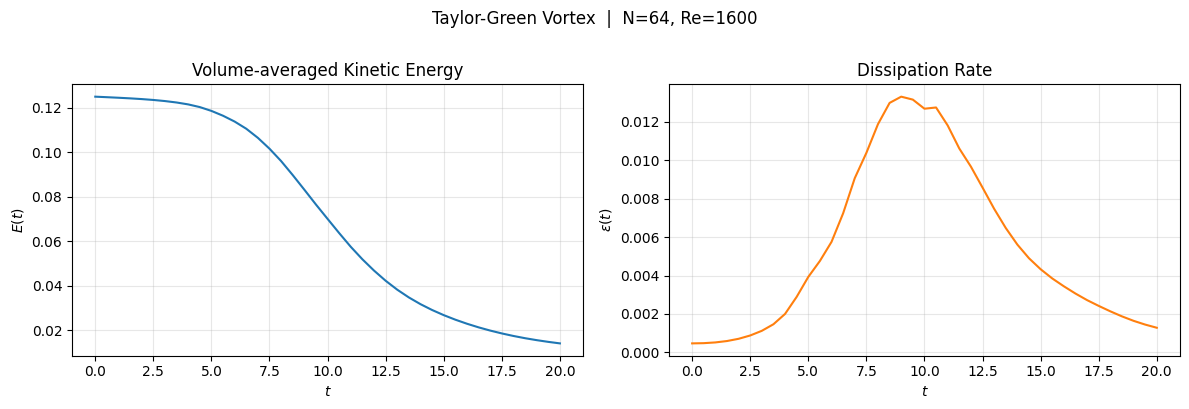

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(times, energies, lw=1.5)
axes[0].set_xlabel('$t$')
axes[0].set_ylabel('$E(t)$')
axes[0].set_title('Volume-averaged Kinetic Energy')
axes[0].grid(True, alpha=0.3)

axes[1].plot(times, dissipations, lw=1.5, color='C1')
axes[1].set_xlabel('$t$')
axes[1].set_ylabel(r'$\varepsilon(t)$')
axes[1].set_title('Dissipation Rate')
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Taylor-Green Vortex  |  N={N}, Re={Re}', y=1.01)
plt.tight_layout()
plt.show()

## Results — Energy Spectrum

At late times the inertial sub-range shows a $k^{-5/3}$ Kolmogorov scaling.
The dealiasing cutoff at $k = N/3$ is visible as the drop-off on the right.

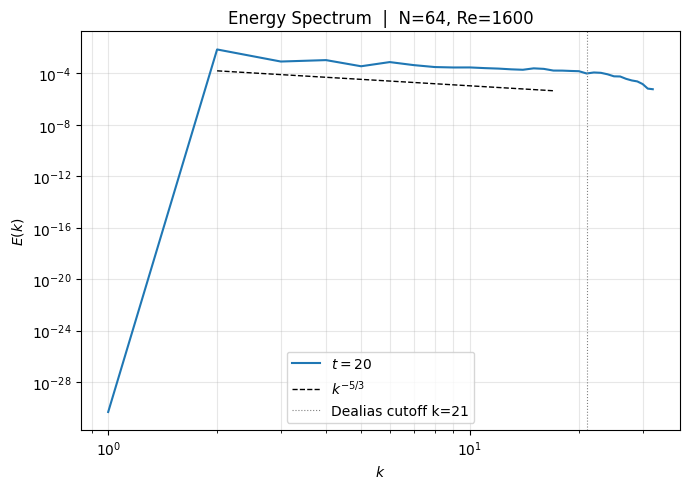

In [ ]:
spec   = energy_spectrum(state)
k_vals = np.arange(len(spec))

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(k_vals[1:], np.array(spec[1:]), lw=1.5, label=f'$t = {T:.0f}$')

# Kolmogorov -5/3 reference line
k_ref = k_vals[2:18]
ax.loglog(k_ref, 5e-4 * k_ref**(-5/3), 'k--', lw=1, label=r'$k^{-5/3}$')

ax.axvline(N // 3, color='gray', lw=0.8, ls=':', label=f'Dealias cutoff k={N//3}')
ax.set_xlabel('$k$')
ax.set_ylabel('$E(k)$')
ax.set_title(f'Energy Spectrum  |  N={N}, Re={Re}')
ax.legend()
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## Results — Vorticity Cross-Section

The $z$-component of vorticity $\omega_z = \partial v/\partial x - \partial u/\partial y$
at the $z=0$ plane shows the fine-scale turbulent structure at late times.

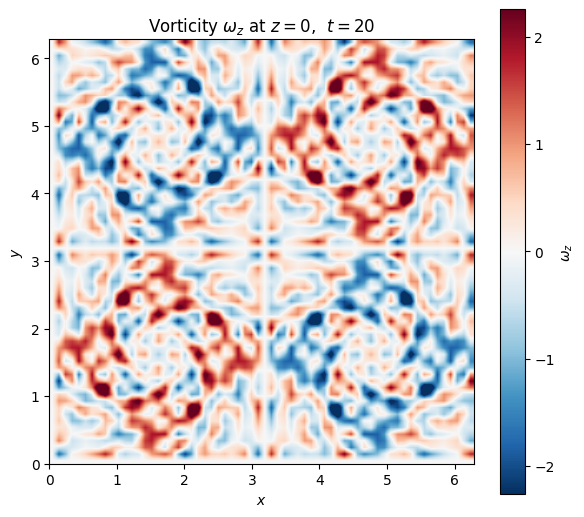

In [ ]:
uh_f, vh_f, wh_f = state

dvdx_f = jnp.fft.ifftn(1j * KX * vh_f * dealias).real
dudy_f = jnp.fft.ifftn(1j * KY * uh_f * dealias).real
omega_z = np.array(dvdx_f - dudy_f)

fig, ax = plt.subplots(figsize=(6, 6))
vmax = np.percentile(np.abs(omega_z), 99)
im = ax.imshow(
    omega_z[:, :, 0],
    origin='lower',
    extent=[0, 2*np.pi, 0, 2*np.pi],
    cmap='RdBu_r',
    vmin=-vmax, vmax=vmax,
    interpolation='bilinear',
)
plt.colorbar(im, ax=ax, label=r'$\omega_z$', shrink=0.85)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title(rf'Vorticity $\omega_z$ at $z=0$,  $t={T:.0f}$')
plt.tight_layout()
plt.show()

## Why JAX Instead of NumPy?

This simulation could be written with NumPy, but JAX provides two concrete advantages.

**1. JIT compilation**

For NumPy, each `fftn`, multiply, add is a separate Python-dispatched call. JAX's `@jax.jit` traces `rk2_step` once, compiles the entire two-stage RK2 step (both calls to `compute_rhs`, all 30+ FFTs, all array operations) into a single XLA kernel, and runs every subsequent time step without touching Python. The 2000-step loop runs entirely in compiled code.

**2. GPU/TPU acceleration with no code changes**

NumPy runs on CPU only. JAX runs the identical code on GPU or TPU with no additional rewriting. Swapping hardware requires only changing the JAX device. Part 1 completed in ~600 s on my local machine's CPU; the same run on a Colab T4 GPU takes under a minute. At $N = 256$ or $N = 512$, where each 3-D FFT operates on tens of millions of points, this gap would become much more noticeable.

**3. Vectorisation over parameters with `jax.vmap`**

NumPy has no equivalent of `vmap`. A Reynolds number sweep in NumPy requires a Python `for` loop that dispatches one kernel per Re value sequentially. `jax.vmap` compiles a single kernel that advances all Re values in parallel on GPU. In Part 2 of this notebook, four simulations at Re = 400, 800, 1600, 3200 are batched into one `step_batch` call, taking roughly the same wall time as a single run on GPU.

**Automatic differentiation (unused here, but available)**

JAX can differentiate through the entire time loop via `jax.grad`. This is not needed for a forward simulation, but it enables adjoint-based sensitivity analysis, i.e., computing how the final state changes with respect to initial conditions or parameters, without deriving or coding adjoint equations by hand. NumPy has no equivalent.

**What NumPy would still be fine for**

Post-processing: the energy spectrum binning (`np.add.at`) and all plotting use NumPy directly, since those run once after the simulation and have no need for compilation or GPU execution.

---

## Part 2 — Reynolds Number Sweep with `jax.vmap`

`jax.vmap` vectorises a function over a leading **batch dimension**. Instead of a Python `for re in Re_values` loop which dispatches one XLA kernel per Re value, `vmap` fuses all Re values into a single kernel. On a GPU the batch computes on parallel thread blocks; on CPU, XLA applies SIMD vectorisation across the batch.

**One required change.** In Part 1, `nu` is captured from the enclosing scope as a Python float. `vmap` cannot vary a closure variable across the batch, so `nu` must become an explicit argument. The grid arrays `KX, KY, KZ, K2,
dealias` remain closures as they are identical for every Re and do not vary across the batch.

In [ ]:
def compute_rhs_nu(state, nu):
    uh, vh, wh = state

    uhd = uh * dealias
    vhd = vh * dealias
    whd = wh * dealias

    u = jnp.fft.ifftn(uhd).real
    v = jnp.fft.ifftn(vhd).real
    w = jnp.fft.ifftn(whd).real

    dudx = jnp.fft.ifftn(1j * KX * uhd).real
    dudy = jnp.fft.ifftn(1j * KY * uhd).real
    dudz = jnp.fft.ifftn(1j * KZ * uhd).real
    dvdx = jnp.fft.ifftn(1j * KX * vhd).real
    dvdy = jnp.fft.ifftn(1j * KY * vhd).real
    dvdz = jnp.fft.ifftn(1j * KZ * vhd).real
    dwdx = jnp.fft.ifftn(1j * KX * whd).real
    dwdy = jnp.fft.ifftn(1j * KY * whd).real
    dwdz = jnp.fft.ifftn(1j * KZ * whd).real

    Nuh = jnp.fft.fftn(-(u*dudx + v*dudy + w*dudz)) * dealias
    Nvh = jnp.fft.fftn(-(u*dvdx + v*dvdy + w*dvdz)) * dealias
    Nwh = jnp.fft.fftn(-(u*dwdx + v*dwdy + w*dwdz)) * dealias

    kdotN = KX*Nuh + KY*Nvh + KZ*Nwh
    Nuh = Nuh - kdotN / K2_safe * KX
    Nvh = Nvh - kdotN / K2_safe * KY
    Nwh = Nwh - kdotN / K2_safe * KZ

    return (
        Nuh - nu * K2 * uh,
        Nvh - nu * K2 * vh,
        Nwh - nu * K2 * wh,
    )


def rk2_step_nu(state, nu):
    k1 = compute_rhs_nu(state, nu)
    state_pred = tuple(s + dt * f for s, f in zip(state, k1))
    k2 = compute_rhs_nu(state_pred, nu)
    return tuple(
        s + 0.5 * dt * (f1 + f2)
        for s, f1, f2 in zip(state, k1, k2)
    )


def diagnostics_nu(state, nu):
    """Returns JAX scalars. float() calls removed so vmap can trace through."""
    uh, vh, wh = state
    norm = float(N) ** 6
    amp2 = jnp.abs(uh)**2 + jnp.abs(vh)**2 + jnp.abs(wh)**2
    E   = 0.5 * jnp.sum(amp2) / norm
    eps = nu  * jnp.sum(K2 * amp2) / norm
    return E, eps


print("compute_rhs_nu, rk2_step_nu, diagnostics_nu defined.")

compute_rhs_nu, rk2_step_nu, diagnostics_nu defined.


### Batch Setup

Each simulation shares the same initial condition but a different viscosity `nu`.
`jnp.stack` adds a leading axis of size `n_Re`, turning each `(N, N, N)`
field into `(n_Re, N, N, N)`.

`jax.vmap(f, in_axes=(0, 0))` accomplishes the following: *map over axis 0 of the first argument which is the state pytree $\texttt{(uh, vh, wh)}$, and axis 0 of the
second argument (nu).* Each element of the pytree, called a *leaf*, is treated independently. Inside the vmapped function every array retains its original `(N, N, N)` shape.

In [ ]:
Re_sweep = jnp.array([400., 800., 1600., 3200.])
nu_sweep = 1.0 / Re_sweep
n_Re     = len(Re_sweep)

# Same initial condition for all Re; add a batch axis: (N,N,N) → (n_Re, N,N,N)
states_batch = tuple(
    jnp.stack([arr] * n_Re)
    for arr in (uh0, vh0, wh0)
)

# vmap over axis-0 of state (each leaf) and axis-0 of nu
step_batch = jax.jit(jax.vmap(rk2_step_nu,    in_axes=(0, 0)))
diag_batch = jax.jit(jax.vmap(diagnostics_nu, in_axes=(0, 0)))

print(f"Re values             : {np.array(Re_sweep).astype(int).tolist()}")
print(f"nu values             : {np.array(nu_sweep)}")
print(f"Shape of one uh array : {states_batch[0].shape[1:]}  (batch size {n_Re})")
print(f"Total state size      : {states_batch[0].nbytes * 3 / 1e6:.0f} MB")

Re values             : [400, 800, 1600, 3200]
nu values             : [0.0025    0.00125   0.000625  0.0003125]
Shape of one uh array : (64, 64, 64)  (batch size 4)
Total state size      : 50 MB


### Time Loop

The loop structure is identical to Part 1. The only difference is that
`step_batch` advances all four Re values in a single XLA call, and
`diag_batch` returns a `(4,)` array of energies and dissipations rather
than a scalar.

**GPU:** on a single GPU, compute and memory traffic scale proportionally
with batch size, so wall time scales linearly regardless of grid size.
On a Colab T4 it takes 26.3 s for one Re, 108.1 s for four Re (~4×).
The vmap benefit is a single fused XLA kernel launch per step instead of
four Python-dispatched ones. The overhead per Re is under 0.4 ms per step. True parallel speedup across simulations requires multiple GPUs (`jax.pmap`).

**CPU:** `vmap` applies SIMD vectorisation within a single thread, not
true multi-core parallelism. For an FFT-heavy workload the four simulations
effectively run serially at the hardware level, so roughly 4× the
single-Re wall time is expected.

In [ ]:
E0_all, eps0_all = diag_batch(states_batch, nu_sweep)
times_s  = [0.0]
E_hist   = [np.array(E0_all)]
eps_hist = [np.array(eps0_all)]

print("Compiling vmapped kernel ...", end=" ", flush=True)
_ = jax.block_until_ready(step_batch(states_batch, nu_sweep))
print("done.")

t_wall = time.perf_counter()

for step in range(1, n_steps + 1):
    states_batch = step_batch(states_batch, nu_sweep)

    if step % log_freq == 0:
        t = step * dt
        E_all, eps_all = diag_batch(states_batch, nu_sweep)
        times_s.append(t)
        E_hist.append(np.array(E_all))
        eps_hist.append(np.array(eps_all))

        if step % (log_freq * 10) == 0:
            line = "  ".join(
                f"Re{int(r)}: ε={float(e):.3e}"
                for r, e in zip(Re_sweep, eps_all)
            )
            print(f"t={t:5.2f}  {line}")

jax.block_until_ready(states_batch[0])
elapsed = time.perf_counter() - t_wall
print(f"\n{n_steps} steps × {n_Re} Re values in {elapsed:.1f} s "
      f"({1000 * elapsed / n_steps:.2f} ms/step)")

Compiling vmapped kernel ... done.
t= 5.00  Re400: ε=9.172e-03  Re800: ε=6.342e-03  Re1600: ε=3.929e-03  Re3200: ε=2.241e-03
t=10.00  Re400: ε=9.203e-03  Re800: ε=1.101e-02  Re1600: ε=1.268e-02  Re3200: ε=1.235e-02
t=15.00  Re400: ε=2.474e-03  Re800: ε=3.127e-03  Re1600: ε=4.330e-03  Re3200: ε=5.980e-03
t=20.00  Re400: ε=1.098e-03  Re800: ε=1.304e-03  Re1600: ε=1.283e-03  Re3200: ε=2.030e-03

2000 steps × 4 Re values in 108.1 s (54.07 ms/step)


### Results — Re Dependence

Higher Re delays the dissipation peak and sharpens it. At higher Re, viscosity is weaker relative to inertia, so the nonlinear term dominates for longer and transfers energy from the large injection scale ($k=1$) down to progressively smaller scales more rapidly. This cascade concentrates more energy at the small dissipative scales before
viscosity can act, producing a taller and narrower $\varepsilon$ peak. At $Re = 400$ the flow is only weakly turbulent. Viscosity damps the cascade early and $\varepsilon$ is broad and low. At $Re = 3200$ the cascade runs further before viscosity intervenes, and the peak is later, taller, and narrower.

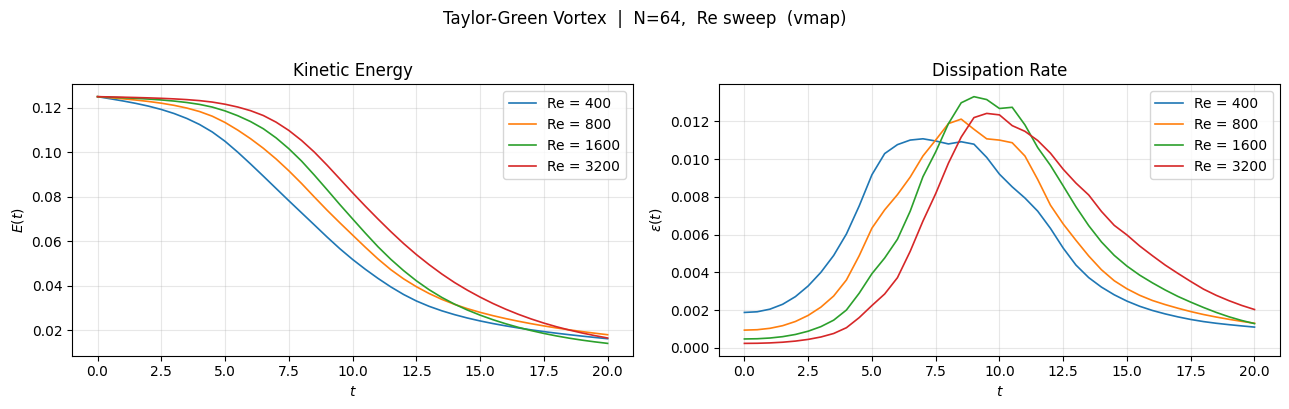

In [ ]:
E_arr   = np.array(E_hist)    # (n_time, n_Re)
eps_arr = np.array(eps_hist)  # (n_time, n_Re)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for i, re in enumerate(np.array(Re_sweep).astype(int)):
    axes[0].plot(times_s, E_arr[:, i],   lw=1.2, label=f'Re = {re}')
    axes[1].plot(times_s, eps_arr[:, i], lw=1.2, label=f'Re = {re}')

axes[0].set_xlabel('$t$');  axes[0].set_ylabel('$E(t)$')
axes[0].set_title('Kinetic Energy')
axes[0].legend();  axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('$t$');  axes[1].set_ylabel(r'$\varepsilon(t)$')
axes[1].set_title('Dissipation Rate')
axes[1].legend();  axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Taylor-Green Vortex  |  N={N},  Re sweep  (vmap)', y=1.01)
plt.tight_layout()
plt.show()